In [1]:
!pip install -q kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Dataset downloaded successfully!")
print(dataset_path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset downloaded successfully!
/kaggle/input/cat-and-dog


In [2]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt

BASE_PATH = dataset_path

train_dir = os.path.join(BASE_PATH, 'training_set/training_set')
validation_dir = os.path.join(BASE_PATH, 'test_set/test_set')

BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Loading Training Dataset:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

print("\nLoading Validation Dataset:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir, shuffle=True, batch_size=BATCH_SIZE, image_size=IMG_SIZE)

val_batches = tf.data.experimental.cardinality(val_dataset)
test_dataset = val_dataset.take(val_batches // 2)
val_dataset = val_dataset.skip(val_batches // 2)

print(f"\nNumber of training batches: {tf.data.experimental.cardinality(train_dataset)}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_dataset)}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_dataset)}")

# Optimization for faster data loading
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

Loading Training Dataset:
Found 8005 files belonging to 2 classes.

Loading Validation Dataset:
Found 2023 files belonging to 2 classes.

Number of training batches: 251
Number of validation batches: 32
Number of test batches: 32


In [3]:
# ResNet50 requires a specific preprocessing function
preprocess_input = tf.keras.applications.resnet50.preprocess_input

# 1. Load Pre-trained ResNet-50 Model
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 2. Freeze the base model
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)  # Regularization
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x) # Binary classification (Cat vs Dog)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1)         │      2,049 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,589,761 (89.99 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Training the Transfer Learning Model...
Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1650s 7s/step - accuracy: 0.9598 - loss: 0.1010 - val_accuracy: 0.9880 - val_loss: 0.0411
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1582s 6s/step - accuracy: 0.9879 - loss: 0.0333 - val_accuracy: 0.9890 - val_loss: 0.0378
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1596s 6s/step - accuracy: 0.9904 - loss: 0.0250 - val_accuracy: 0.9910 - val_loss: 0.0350
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1598s 6s/step - accuracy: 0.9935 - loss: 0.0197 - val_accuracy: 0.9910 - val_loss: 0.0351
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 1567s 6s/step - accuracy: 0.9935 - loss: 0.0187 - val_accuracy: 0.9890 - val_loss: 0.0374

--- Evaluating on Test Set ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 178s 6s/step - accuracy: 0.9902 - loss: 0.0277
Test Accuracy: 0.9902
Test Loss: 0.0277


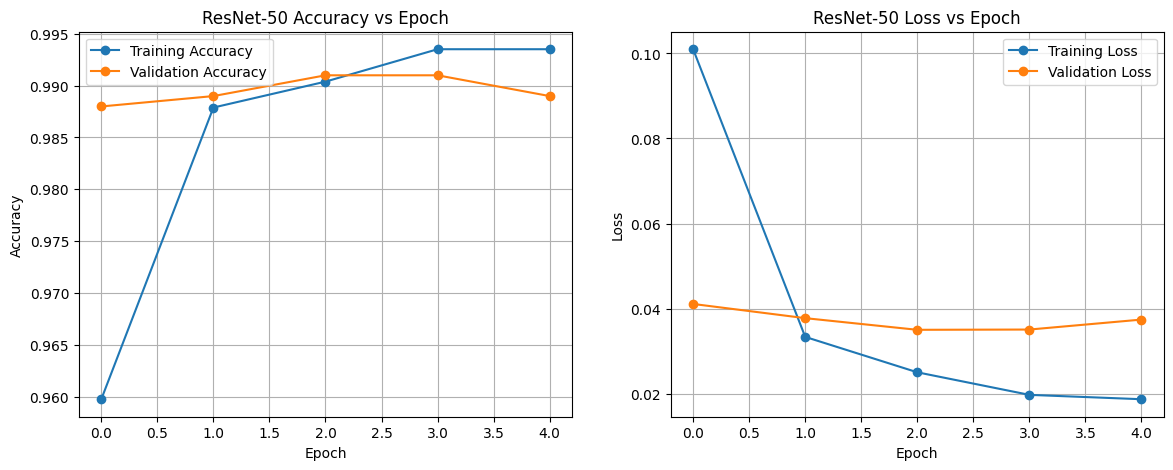

In [4]:
print("Training the Transfer Learning Model...")
history = model.fit(
    train_dataset,
    epochs=5,
    validation_data=val_dataset
)

print("\n--- Evaluating on Test Set ---")
loss, accuracy = model.evaluate(test_dataset)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
ax1.set_title('ResNet-50 Accuracy vs Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss Plot
ax2.plot(history.history['loss'], label='Training Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='o')
ax2.set_title('ResNet-50 Loss vs Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.show()

In [5]:
!pip install -q transformers

Loading Hugging Face ViT Model...


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

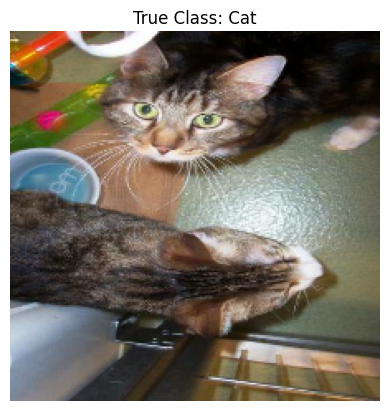


Model Predictions Comparison: 
1. Custom Fine-Tuned ResNet-50 Prediction: Cat (Probability of Dog: 0.0004)

2. Hugging Face ViT Top-3 Predictions:
   - tabby, tabby cat: 0.5401
   - Egyptian cat: 0.2040
   - tiger cat: 0.1994
Dhanya - 24BAD019


In [6]:
from transformers import pipeline
from PIL import Image
import numpy as np

print("Loading Hugging Face ViT Model...")
hf_classifier = pipeline("image-classification", model="google/vit-base-patch16-224")

for images, labels in test_dataset.take(1):
    sample_image = images[0].numpy().astype("uint8")
    sample_label = labels[0].numpy()
    break

pil_image = Image.fromarray(sample_image)

hf_predictions = hf_classifier(pil_image)

resnet_prob = model.predict(np.expand_dims(sample_image, axis=0), verbose=0)[0][0]
resnet_pred_class = "Dog" if resnet_prob > 0.5 else "Cat"
true_class = "Dog" if sample_label == 1 else "Cat"

plt.imshow(sample_image)
plt.title(f"True Class: {true_class}")
plt.axis('off')
plt.show()

print("\nModel Predictions Comparison: ")
print(f"1. Custom Fine-Tuned ResNet-50 Prediction: {resnet_pred_class} (Probability of Dog: {resnet_prob:.4f})")
print(f"\n2. Hugging Face ViT Top-3 Predictions:")
for pred in hf_predictions[:3]:
    print(f"   - {pred['label']}: {pred['score']:.4f}")

print("Dhanya - 24BAD019")